<a href="https://colab.research.google.com/github/nam3user/comp_ling-course/blob/main/convnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практический семинар: CNN для Fashion-MNIST

1.  Подготовка данных
2.  Архитектура "учителя" (образец)
3.  **Ваша модель** (практика)
4.  Обучение и оценка
5.  Эксперимент


## Часть 1: загрузка и подготовка данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# 1. Загрузка Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# 2. Нормализация (делим на 255)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Преобразуем метки в one-hot encoding (готовый код)
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# 4. Добавляем размерность канала (для Conv2D)
x_train = np.expand_dims(x_train, axis=-1)  # (60000,28,28,1)
x_test = np.expand_dims(x_test, axis=-1)    # (10000,28,28,1)

print(f"x_train shape: {x_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")

# Словарь классов
class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандаль', 'Рубашка', 'Кроссовок', 'Сумка', 'Ботильон']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train_cat shape: (60000, 10)


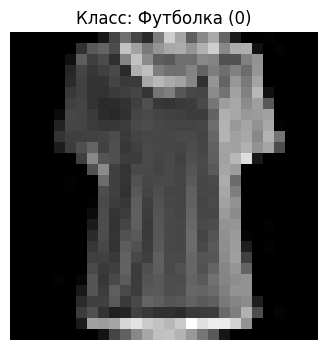

Индекс: 49635
Размер изображения: (28, 28, 1)
Метка (число): 0
Метка (текст): Футболка


In [ ]:
# Визуализация случайного изображения
import random

# Случайный индекс
idx = random.randint(0, len(x_train) - 1)

# Получаем изображение и метку
image = x_train[idx]
label = y_train[idx]

# Создаем график
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')  # Убираем размерность канала для отображения
plt.title(f"Класс: {class_names[label]} ({label})")
plt.axis('off')
plt.show()

# Дополнительная информация
print(f"Индекс: {idx}")
print(f"Размер изображения: {image.shape}")
print(f"Метка (число): {label}")
print(f"Метка (текст): {class_names[label]}")

## Часть 2: архитектура 'Учителя' (образец)

In [4]:
# Модель 'Учитель'
teacher_model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

teacher_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Вопросы для понимания (обсудите в группе или ответьте письменно):
1.  **Flatten:** Зачем нужен этот слой? Что он делает с данными?
2.  **MaxPooling2D:** Какую функцию выполняет? Почему он следует за Conv2D?
3.  **Последний Dense слой:** Почему в нём 10 нейронов и активация `softmax`?

---

## Часть 3: ваша модель (практика сборки)

**Задание:** соберите CNN **точно по этой спецификации**:
1.  Conv2D: 16 фильтров, размер 3x3, активация `relu`, `input_shape=(28,28,1)`
2.  MaxPooling2D: пул 2x2
3.  Conv2D: 32 фильтра, 3x3, `relu`
4.  MaxPooling2D: 2x2
5.  Flatten
6.  Dense: 64 нейрона, `relu`
7.  Dense: 10 нейронов, `softmax`

**Заполните пропуски ниже**

In [2]:
# Ваша модель (студент)
student_model = keras.Sequential([
    # Слой 1: Conv2D (16 фильтров, 3x3, relu, правильный input_shape)
    ### ВАШ КОД ЗДЕСЬ ###
    # keras.layers.Conv2D(...),

    # Слой 2: MaxPooling2D (2,2)
    ### ВАШ КОД ЗДЕСЬ ###

    # Слой 3: Conv2D (32 фильтра, 3x3, relu)
    ### ВАШ КОД ЗДЕСЬ ###

    # Слой 4: MaxPooling2D (2,2)
    ### ВАШ КОД ЗДЕСЬ ###

    # Слой 5: Flatten
    ### ВАШ КОД ЗДЕСЬ ###

    # Слой 6: Dense (64 нейрона, relu)
    ### ВАШ КОД ЗДЕСЬ ###

    # Слой 7: Dense (10 нейронов, softmax)
    ### ВАШ КОД ЗДЕСЬ ###
 ])
student_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

---

In [ ]:
student_model = keras.Sequential([
    keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

student_model.summary()

## Часть 4: компиляция и обучение

In [5]:
# Учитель: компиляция
teacher_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [6]:
# Учитель: обучение (5 эпох)
teacher_history = teacher_model.fit(x_train, y_train,  # Используем исходные метки (не one-hot)
                                    epochs=5,
                                    validation_split=0.2,
                                    verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.7707 - loss: 0.6407 - val_accuracy: 0.8731 - val_loss: 0.3518
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.8820 - loss: 0.3230 - val_accuracy: 0.8869 - val_loss: 0.3014
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.8999 - loss: 0.2702 - val_accuracy: 0.8953 - val_loss: 0.2864
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9177 - loss: 0.2279 - val_accuracy: 0.9019 - val_loss: 0.2702
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9262 - loss: 0.1995 - val_accuracy: 0.9035 - val_loss: 0.2731


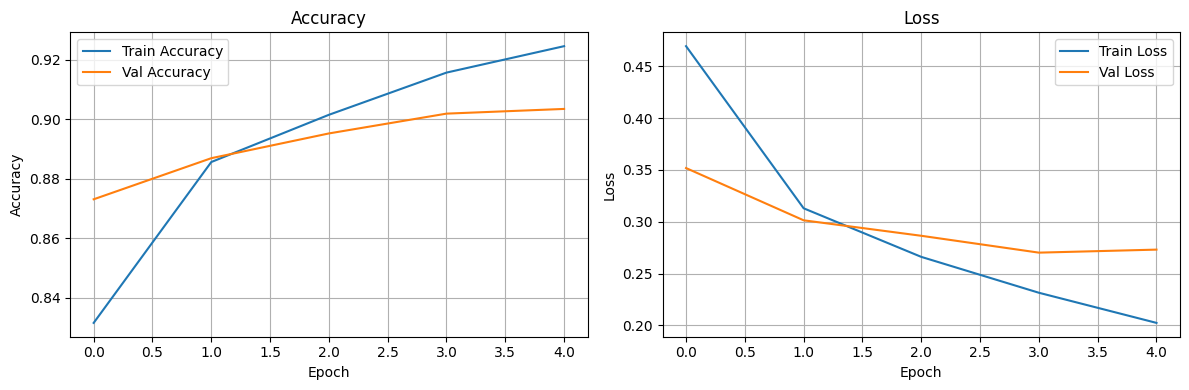

In [7]:
# Визуализация процесса обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# График точности
axes[0].plot(teacher_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(teacher_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# График потерь
axes[1].plot(teacher_history.history['loss'], label='Train Loss')
axes[1].plot(teacher_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Задание:**
1.  Скомпилируйте `student_model` с оптимизатором **`sgd`**
2.  Добавьте метрику **`'sparse_top_k_categorical_accuracy'`** к списку метрик
3.  Обучите модель на **3 эпохи** с `validation_split=0.2`
4.  Постройте график обучения

In [ ]:
# 1. Компиляция вашей модели (sgd, sparse_categorical_crossentropy, accuracy + sparse_top_k_categorical_accuracy)
### ВАШ КОД ЗДЕСЬ ###
# student_model.compile(...)

# 2. Обучение (3 эпохи, validation_split=0.2)
### ВАШ КОД ЗДЕСЬ ###
# student_history = student_model.fit(...)

# 3. График обучения

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9150 - loss: 0.2306 - sparse_top_k_categorical_accuracy: 0.9991 - val_accuracy: 0.9033 - val_loss: 0.2696 - val_sparse_top_k_categorical_accuracy: 0.9986
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9170 - loss: 0.2251 - sparse_top_k_categorical_accuracy: 0.9990 - val_accuracy: 0.9032 - val_loss: 0.2706 - val_sparse_top_k_categorical_accuracy: 0.9983
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9186 - loss: 0.2253 - sparse_top_k_categorical_accuracy: 0.9992 - val_accuracy: 0.9039 - val_loss: 0.2675 - val_sparse_top_k_categorical_accuracy: 0.9986


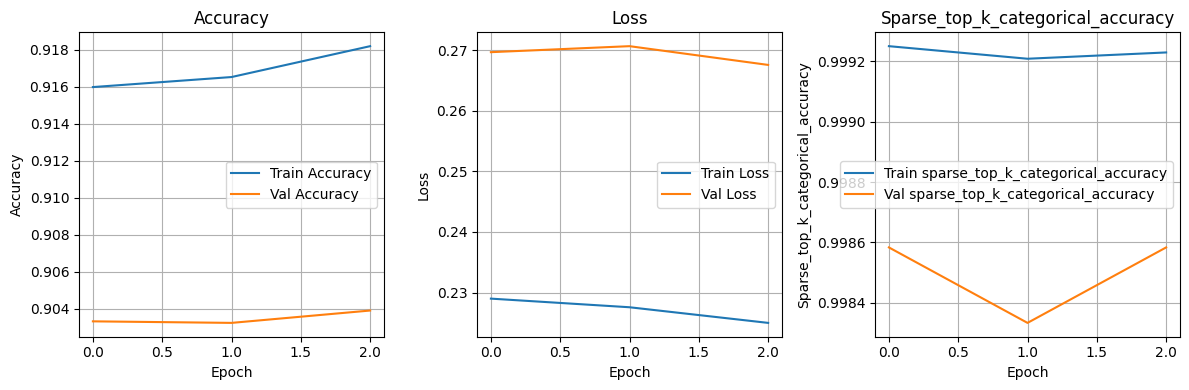

In [12]:
student_model.compile(optimizer='sgd',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy', 'sparse_top_k_categorical_accuracy'])

student_history = student_model.fit(x_train, y_train,  # Используем исходные метки (не one-hot)
                                    epochs=3,
                                    validation_split=0.2,
                                    verbose=1)

# Визуализация процесса обучения
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# График точности
axes[0].plot(student_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(student_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# График потерь
axes[1].plot(student_history.history['loss'], label='Train Loss')
axes[1].plot(student_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(student_history.history['sparse_top_k_categorical_accuracy'], label='Train sparse_top_k_categorical_accuracy')
axes[2].plot(student_history.history['val_sparse_top_k_categorical_accuracy'], label='Val sparse_top_k_categorical_accuracy')
axes[2].set_title('Sparse_top_k_categorical_accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Sparse_top_k_categorical_accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

---

## Часть 5: оценка и сравнение моделей

In [ ]:
from sklearn.metrics import classification_report

# 1. Оценка точности на тесте
teacher_test_loss, teacher_test_acc = teacher_model.evaluate(x_test, y_test, verbose=0)
print(f"\nМодель 'Учитель' на тесте:")
print(f"  Loss:     {teacher_test_loss:.4f}")
print(f"  Accuracy: {teacher_test_acc:.4f}")

# 2. Подробный отчёт
y_pred_teacher = teacher_model.predict(x_test)
y_pred_classes_teacher = np.argmax(y_pred_teacher, axis=1)
print("\nОтчёт classification_report для учителя:")
print(classification_report(y_test, y_pred_classes_teacher, target_names=class_names))


Модель 'Учитель' на тесте:
  Loss:     0.3017
  Accuracy: 0.9095
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

Отчёт classification_report для учителя:
              precision    recall  f1-score   support

    Футболка       0.83      0.84      0.84      1000
       Брюки       0.99      0.98      0.99      1000
      Свитер       0.90      0.82      0.86      1000
      Платье       0.91      0.93      0.92      1000
      Пальто       0.87      0.87      0.87      1000
     Сандаль       0.97      0.99      0.98      1000
     Рубашка       0.71      0.78      0.74      1000
   Кроссовок       0.97      0.94      0.96      1000
       Сумка       0.98      0.98      0.98      1000
    Ботильон       0.96      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



**Задание:**
1.  Оцените вашу модель (`student_model`) на тестовых данных. Получите `loss` и `accuracy`.
2.  Сравните accuracy с моделью учителя. Какая лучше и почему (возможные причины)?
3.  Выведите `classification_report` для вашей модели.


In [ ]:
# 1. Оценка точности вашей модели на тесте
### ВАШ КОД ЗДЕСЬ ###
# student_test_loss, student_test_acc = student_model.evaluate(...)

# 2. Сравнение
print(f"\nСравнение точности на тесте:")
print(f"  Учитель (adam):  {teacher_test_acc:.4f}")
# print(f"  Ваша модель (sgd): {student_test_acc:.4f}")

# 3. Отчёт classification_report для вашей модели
### ВАШ КОД ЗДЕСЬ ###
# y_pred_student = student_model.predict(...)
# y_pred_classes_student = np.argmax(...)
# print(classification_report(...))

---

## Часть 6: эксперимент

**Задание:** модифицируйте вашу модель `student_model`, добавив слой **`Dropout(0.3)`** после первого `Dense`-слоя (с 64 нейронами). Переобучите модель на 3 эпохи. Как изменилась точность на валидации и тесте? Стала ли модель лучше обобщаться?

*Подсказка: используйте `keras.layers.Dropout(0.3)`.*


In [ ]:
# Ваш экспериментальный код здесь


---

## Итоги семинара

1.  Вы подготовили данные для CNN
2.  Построили модель по спецификации
3.  Сравнили оптимизаторы (`adam` vs `sgd`)
4.  Оценили модель с помощью метрик и отчёта